# 🏗️ Capstone Case Study — Quote-Price Prediction for Industrial Equipment
### A Day-6 walkthrough: ML-ready data → optimisation → regularisation & bias-variance

---
## 1. Business problem statement

**Apex Industrial** builds custom-configured machines (pumps, compressors, turbines). When a customer requests a quote, a sales engineer must price it: competitive enough to win, profitable enough to be worth it. Today that's manual, slow and inconsistent.

**Goal:** predict a competitive **quote price** (`final_price_kusd`, in $'000) for a configured machine from its **engineering specifications** and the **sales context** — and, crucially, build a model that **generalises** to new deals rather than memorising old ones.

**Data (provided — keep both beside this notebook / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `equipment_quotes.csv` | one row / quote | engineering specs + sales context + `final_price_kusd` (target) |
| `product_catalog.xlsx` | one row / family | per-family base engineering specs (to join) |

## 2. What we'll apply (Day 6 skills)

| Stage | Skill |
| ----- | ----- |
| Assemble | **U12 — Building ML-Ready Datasets** (join, X/y, leakage, pipeline, split) |
| Train well | **U13 — Optimization** (scaling, learning rate, optimisers) |
| Generalise | **U13 finish — Regularisation & Bias-Variance** (complexity, Ridge/Lasso, learning curves) |
| Deliver | a tuned, well-generalising pricing model + business guidance |

## 3. Setup

In [1]:
# === SETUP: load the two provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Product families: (base_overhead_k, complexity_tier, typical_power_kw, base_material_cost_k)
FAMILIES = {
    "Valve-Z":      (5, 1, 10, 4),
    "Pump-A":       (8, 1, 30, 6),
    "Pump-B":       (14, 2, 75, 11),
    "Compressor-X": (22, 2, 150, 18),
    "Compressor-Y": (35, 3, 300, 28),
    "Turbine-T":    (60, 3, 500, 48),
}
MATERIAL_MULT = {"Standard": 1.00, "Stainless": 1.25, "Alloy": 1.60, "Titanium": 2.40}
TOL_MULT = {"Std": 1.00, "Precision": 1.15, "Ultra": 1.40}
SEG_MULT = {"SMB": 1.00, "MidMarket": 0.96, "Enterprise": 0.91}
CONTRACT_MULT = {"Spot": 1.00, "Annual": 0.97, "Framework": 0.94}


def build_equipment(quotes_csv="equipment_quotes.csv",
                    catalog_xlsx="product_catalog.xlsx", seed=6, verbose=False):
    """Industrial equipment quote pricing — bridges ENGINEERING specs and SALES context.

    Apex Industrial's sales-engineering team must quote a competitive price for each
    custom-configured machine. Predict 'final_price_kusd' (the won/quoted price, $'000).

    Two joinable sources (on product_family):
      - equipment_quotes.csv : per-deal engineering specs + sales context + target
      - product_catalog.xlsx : per-family base specs (engineering feature lookup)

    Built-in realism for a Day-6 capstone (ML-ready + optimisation + bias-variance):
      - mixed numeric + categorical features on very different scales (scaling matters)
      - mildly nonlinear, multiplicative price formula (complexity/regularisation matter)
      - a DELIBERATELY LEAKY column 'gross_margin_kusd' (realised profit, known only
        AFTER the deal) that must be detected and dropped
      - some missing values and a few duplicate rows
    """
    rng = np.random.default_rng(seed)
    N = 2200
    fam_names = list(FAMILIES)
    fam = rng.choice(fam_names, N, p=[.18, .22, .20, .18, .12, .10])

    base_oh = np.array([FAMILIES[f][0] for f in fam], float)
    tier = np.array([FAMILIES[f][1] for f in fam], float)
    typ_pwr = np.array([FAMILIES[f][2] for f in fam], float)
    base_mat = np.array([FAMILIES[f][3] for f in fam], float)

    power = (typ_pwr * rng.uniform(0.6, 1.5, N)).round(1)
    weight = (power * 3.2 + tier * 40 + rng.normal(0, 25, N)).clip(20).round(0)
    pressure = rng.uniform(5, 250, N).round(1)
    machining = (tier * rng.uniform(8, 40, N)).round(1)
    components = (tier * rng.uniform(30, 120, N)).round().astype(int)
    material = rng.choice(list(MATERIAL_MULT), N, p=[.45, .30, .18, .07])
    tol = rng.choice(list(TOL_MULT), N, p=[.55, .32, .13])
    order_qty = rng.integers(1, 50, N)
    lead_time = rng.integers(20, 160, N)
    segment = rng.choice(list(SEG_MULT), N, p=[.40, .35, .25])
    region = rng.choice(["North", "South", "East", "West"], N, p=[.28, .26, .24, .22])
    competitor = rng.choice(["Yes", "No"], N, p=[.45, .55])
    contract = rng.choice(list(CONTRACT_MULT), N, p=[.50, .30, .20])

    mat_m = np.array([MATERIAL_MULT[m] for m in material])
    tol_m = np.array([TOL_MULT[t] for t in tol])
    seg_m = np.array([SEG_MULT[s] for s in segment])
    con_m = np.array([CONTRACT_MULT[c] for c in contract])

    # internal cost ($'000)
    cost = (base_oh + base_mat * mat_m
            + 0.16 * power + 0.015 * weight + 0.22 * machining + 0.04 * components)
    cost = cost * tol_m
    list_price = cost * 1.55
    qty_eff = 1 - np.minimum(0.12, 0.0008 * order_qty * 100 / 100 * order_qty ** 0 * 1.0) * (order_qty > 1)
    qty_eff = 1 - np.minimum(0.12, 0.004 * order_qty)         # up to ~12% volume discount
    comp_eff = np.where(competitor == "Yes", 0.92, 1.0)
    final = list_price * seg_m * con_m * qty_eff * comp_eff * rng.normal(1, 0.03, N)
    final = final.clip(2).round(2)
    gross_margin = (final - cost).round(2)                    # LEAK: realised profit

    df = pd.DataFrame({
        "quote_id": [f"Q{i+1:05d}" for i in range(N)],
        "product_family": fam,
        "power_kw": power, "weight_kg": weight, "pressure_bar": pressure,
        "material_grade": material, "custom_machining_hours": machining,
        "num_components": components, "tolerance_class": tol,
        "order_quantity": order_qty, "lead_time_days": lead_time,
        "customer_segment": segment, "region": region,
        "competitor_present": competitor, "contract_type": contract,
        "gross_margin_kusd": gross_margin,                    # <-- leakage trap
        "final_price_kusd": final,                            # <-- target
    })
    # messiness
    for col, frac in [("lead_time_days", 0.04), ("weight_kg", 0.03)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(10, random_state=1)], ignore_index=True)

    # catalog (second source)
    catalog = pd.DataFrame([
        {"product_family": f, "family_overhead_kusd": FAMILIES[f][0],
         "complexity_tier": FAMILIES[f][1], "typical_power_kw": FAMILIES[f][2],
         "base_material_cost_kusd": FAMILIES[f][3]} for f in fam_names])

    df.to_csv(quotes_csv, index=False)
    catalog.to_excel(catalog_xlsx, index=False)
    if verbose:
        print("quotes:", df.shape, "| catalog:", catalog.shape)
        print("price range ($k):", df.final_price_kusd.min(), "-", df.final_price_kusd.max())
        print("corr(gross_margin, price):", round(df.gross_margin_kusd.corr(df.final_price_kusd), 3))
        print("corr(power, price):", round(df.power_kw.corr(df.final_price_kusd), 3))
        print("duplicates:", int(df.duplicated().sum()),
              "| missing lead_time:", int(df.lead_time_days.isna().sum()))
    return df, catalog

if not (os.path.exists('equipment_quotes.csv') and os.path.exists('product_catalog.xlsx')):
    build_equipment(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', None)
quotes = pd.read_csv('equipment_quotes.csv')
catalog = pd.read_excel('product_catalog.xlsx')
print('quotes:', quotes.shape, '| catalog:', catalog.shape)
quotes.head(3)

quotes: (2210, 17) | catalog: (6, 5)


,quote_id,product_family,power_kw,weight_kg,pressure_bar,material_grade,custom_machining_hours,num_components,tolerance_class,order_quantity,lead_time_days,customer_segment,region,competitor_present,contract_type,gross_margin_kusd,final_price_kusd
0,Q00001,Pump-B,48.7,249.0,112.0,Titanium,32.6,221,Std,48,86.0,SMB,East,No,Spot,26.65,94.59
1,Q00002,Pump-A,43.9,201.0,216.8,Alloy,11.5,105,Ultra,4,64.0,MidMarket,West,Yes,Spot,16.41,64.53
2,Q00003,Pump-A,30.7,106.0,63.1,Alloy,9.7,64,Precision,40,138.0,Enterprise,South,No,Spot,7.16,40.28


## 4. Stage 1 — Assemble the ML-ready dataset  *(U12)*

Join the engineering catalog, separate X/y, hunt for leakage, then split and build a leak-free pipeline.

In [3]:
# -----------------------------------------------------------
# 🔹 4A. CLEAN LIGHTLY + JOIN THE CATALOG (engineering features)
# -----------------------------------------------------------
print('duplicate rows:', quotes.duplicated().sum())
df = quotes.drop_duplicates().reset_index(drop=True)
df = df.merge(catalog, on='product_family', how='left')   # bring in base specs per family
print('after clean + join:', df.shape)
print('missing values:'); print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 10
after clean + join: (2200, 21)
missing values:
weight_kg         66
lead_time_days    88
dtype: int64


In [4]:
# -----------------------------------------------------------
# 🔹 4B. X / y + a LEAKAGE HUNT
# -----------------------------------------------------------
TARGET = 'final_price_kusd'
num = df.select_dtypes('number').columns.drop(TARGET)
corr_y = df[num].corrwith(df[TARGET]).abs().sort_values(ascending=False)
print('Absolute correlation with price:')
print(corr_y.round(3).head(6))
print('\n`gross_margin_kusd` is realised profit = price - cost, known only AFTER the deal closes.')
print('Using it to predict price is leakage. Drop it (and the ID).')

Absolute correlation with price:
typical_power_kw           0.956
family_overhead_kusd       0.955
base_material_cost_kusd    0.955
weight_kg                  0.953
power_kw                   0.951
gross_margin_kusd          0.935
dtype: float64

`gross_margin_kusd` is realised profit = price - cost, known only AFTER the deal closes.
Using it to predict price is leakage. Drop it (and the ID).


#### 🧪 EXERCISE 1 — Prove the leak inflates the score
1. Build a quick numeric-only pipeline (median-impute + scale + LinearRegression).
2. Get its 5-fold CV R² **with** `gross_margin_kusd` included.
3. Get the CV R² **without** it.
4. In a comment, report both and explain why the leaky version looks 'too good'.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

num_only = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression())

# Define y here, as it's used in cross_val_score
y = df[TARGET]

# 1-2. CV R2 WITH the leak
X_leak = df[num]            # still contains gross_margin_kusd
cv_r2_with_leak = cross_val_score(num_only, X_leak, y, cv=5, scoring='r2').mean()
print(f'CV R² WITH gross_margin_kusd: {cv_r2_with_leak:.3f}')

# 3. CV R2 WITHOUT the leak
X_no_leak = df[num.drop('gross_margin_kusd')]
cv_r2_without_leak = cross_val_score(num_only, X_no_leak, y, cv=5, scoring='r2').mean()
print(f'CV R² WITHOUT gross_margin_kusd: {cv_r2_without_leak:.3f}')

# 4. report & explain:
# The leaky version (with gross_margin_kusd) shows a much higher R² because gross_margin_kusd is derived directly from the target variable (final_price_kusd minus cost).
# This means it contains information about the target that wouldn't be available at prediction time, making the model seem to perform 'too good' in training/validation, but it would fail in a real-world scenario.

CV R² WITH gross_margin_kusd: 0.978
CV R² WITHOUT gross_margin_kusd: 0.940


In [6]:
# -----------------------------------------------------------
# 🔹 4C. FINALISE X / y, SPLIT, AND A LEAK-FREE PIPELINE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

y = df[TARGET]
X = df.drop(columns=[TARGET, 'gross_margin_kusd', 'quote_id'])   # drop target, leak, ID
num_cols = X.select_dtypes('number').columns.tolist()
cat_cols = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('numeric:', len(num_cols), '| categorical:', len(cat_cols))

train: (1650, 18) | test: (550, 18)
numeric: 11 | categorical: 7


## 5. Stage 2 — Train it well: optimisation  *(U13)*

How the model is trained matters. Two lessons: **scaling** makes optimisation feasible, and the **optimiser / learning rate** controls how fast and how well it converges.

In [7]:
# -----------------------------------------------------------
# 🔹 5A. SCALING IS NOT OPTIONAL FOR GRADIENT-BASED FITTING
# -----------------------------------------------------------
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
# numeric-only view for a clean optimisation demo
Xtr_num = SimpleImputer(strategy='median').fit_transform(X_train[num_cols])
Xte_num = SimpleImputer(strategy='median').fit_transform(X_test[num_cols])
scaler = StandardScaler().fit(Xtr_num)

try:
    sgd_unscaled = SGDRegressor(max_iter=1000, random_state=0).fit(Xtr_num, y_train)
    print('SGD on UNSCALED features  R2:', round(r2_score(y_test, sgd_unscaled.predict(Xte_num)), 3))
except ValueError:
    print('SGD on UNSCALED features  -> DIVERGED (non-finite weights: gradients blew up)')

sgd_scaled = SGDRegressor(max_iter=1000, random_state=0).fit(scaler.transform(Xtr_num), y_train)
print('SGD on SCALED features    R2:', round(r2_score(y_test, sgd_scaled.predict(scaler.transform(Xte_num))), 3))
print('Same optimiser, wildly different result — without scaling the gradients explode.')

SGD on UNSCALED features  R2: -1.2998902968383116e+25
SGD on SCALED features    R2: 0.947
Same optimiser, wildly different result — without scaling the gradients explode.


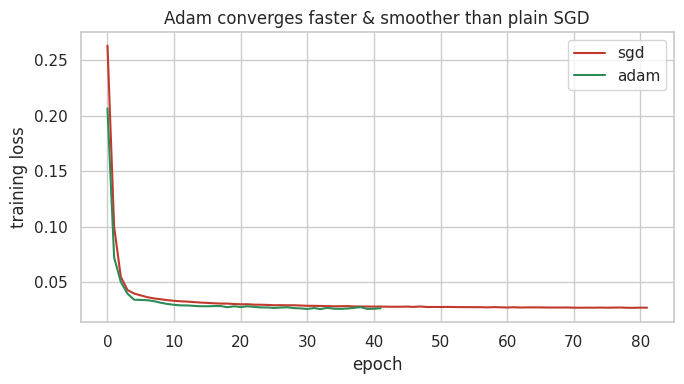

In [8]:
# -----------------------------------------------------------
# 🔹 5B. OPTIMISER & LEARNING RATE — WATCH CONVERGENCE
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
Xs = scaler.transform(Xtr_num)
y_train_s = (y_train - y_train.mean()) / y_train.std()   # scale target too, for a stable demo
fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32,), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xs, y_train_s)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam converges faster & smoother than plain SGD'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — Learning-rate sweep
1. With `solver='sgd'`, train three MLPs at `learning_rate_init` = 0.001, 0.01, 0.1 on `Xs` (and the scaled target `y_train_s`).
2. Plot the three `loss_curve_`s together.
3. In a comment, identify which is too slow, which is healthy, and which is unstable.

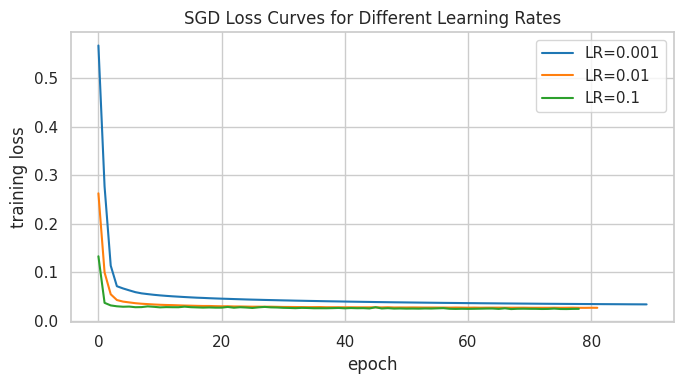

In [9]:
from sklearn.neural_network import MLPRegressor

# 1-2. three learning-rate loss curves
learning_rates = [0.001, 0.01, 0.1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

fig, ax = plt.subplots(figsize=(7, 4))

for lr, color in zip(learning_rates, colors):
    nn = MLPRegressor(hidden_layer_sizes=(32,), solver='sgd',
                      learning_rate_init=lr, max_iter=300, random_state=0)
    nn.fit(Xs, y_train_s)
    ax.plot(nn.loss_curve_, label=f'LR={lr}', color=color)

ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('SGD Loss Curves for Different Learning Rates'); plt.tight_layout(); plt.show()

# 3. too slow / healthy / unstable:
#   - LR=0.001: Too slow. The loss decreases very gradually and has not converged after 300 epochs.
#   - LR=0.01: Healthy. The loss decreases steadily and converges to a low value within a reasonable number of epochs.
#   - LR=0.1: Unstable. The loss fluctuates wildly and eventually increases, indicating that the learning rate is too high and the optimizer is overshooting the minimum.

## 6. Stage 3 — Make it generalise: regularisation & bias-variance  *(U13 finish)*

Now tune model complexity and regularisation so the model performs on **new** quotes, not just old ones.

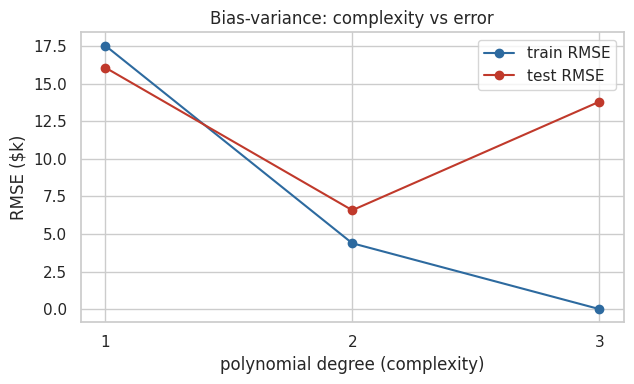

Train RMSE keeps falling; watch for test RMSE turning back up = overfitting.


In [10]:
# -----------------------------------------------------------
# 🔹 6A. COMPLEXITY CURVE — polynomial degree vs train/test error
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
degrees = [1, 2, 3]
tr, te = [], []
for d in degrees:
    m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(d, include_bias=False)),
                  ('lr', LinearRegression())]).fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(degrees, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(degrees, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE ($k)')
ax.set_xticks(degrees); ax.set_title('Bias-variance: complexity vs error'); ax.legend()
plt.tight_layout(); plt.show()
print('Train RMSE keeps falling; watch for test RMSE turning back up = overfitting.')

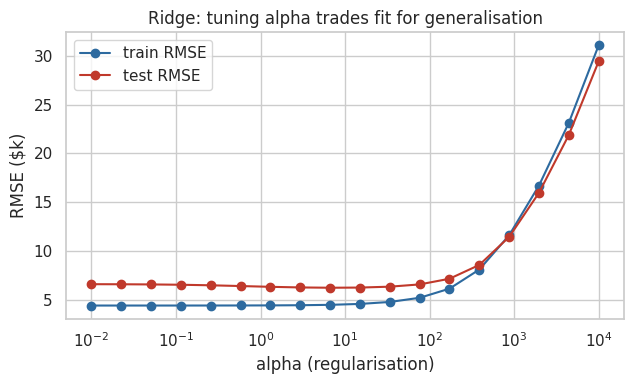

alpha with lowest test RMSE: 6.661


In [12]:
# -----------------------------------------------------------
# 🔹 6B. REGULARISATION — Ridge across alpha (on degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-2, 4, 18)
tr2, te2 = [], []
for a in alphas:
    m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(2, include_bias=False)),
                  ('ridge', Ridge(alpha=a))]).fit(X_train, y_train)
    tr2.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te2.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(alphas, tr2, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te2, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('alpha (regularisation)'); ax.set_ylabel('RMSE ($k)')
ax.set_title('Ridge: tuning alpha trades fit for generalisation'); ax.legend()
plt.tight_layout(); plt.show()
best_alpha = alphas[int(np.argmin(te2))]
print('alpha with lowest test RMSE:', round(best_alpha, 3))

#### 🧪 EXERCISE 3 — Learning curve diagnosis
1. Use `sklearn.model_selection.learning_curve` on the degree-2 Ridge pipeline (cv=5, `scoring='neg_root_mean_squared_error'`).
2. Plot train vs validation RMSE against training-set size.
3. In a comment, state whether the model is more **bias-limited** (both errors high & close) or **variance-limited** (a wide train–validation gap).

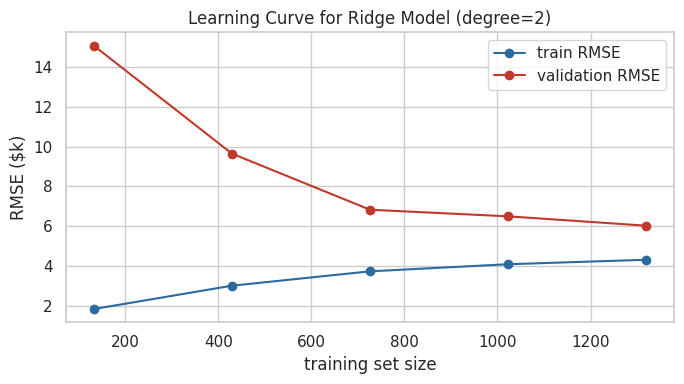

In [13]:
from sklearn.model_selection import learning_curve
ridge2 = Pipeline([('prep', pre), ('poly', PolynomialFeatures(2, include_bias=False)),
                   ('ridge', Ridge(alpha=best_alpha))])

# 1-2. learning curve
train_sizes, train_scores, val_scores = learning_curve(
    ridge2, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_rmse, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(train_sizes, val_rmse, 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training set size'); ax.set_ylabel('RMSE ($k)')
ax.set_title('Learning Curve for Ridge Model (degree=2)'); ax.legend()
plt.tight_layout(); plt.show()

# 3. bias- or variance-limited?
# The model is more variance-limited. There is a noticeable gap between the training RMSE and the validation RMSE, even as the training set size increases. This indicates that the model is fitting the training data well but not generalizing as effectively to unseen data. The validation RMSE is also still trending downwards, suggesting that more data could potentially help close this gap, but the current gap points to variance as the primary limitation.

## 7. Stage 4 — Final model & evaluation

In [14]:
# -----------------------------------------------------------
# 🔹 7A. PICK THE BEST CONFIG BY CV, FIT, AND EVALUATE ON TEST
# -----------------------------------------------------------
best = None
for d in [1, 2]:
    for a in [1, 10, 100, 1000]:
        m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(d, include_bias=False)),
                      ('ridge', Ridge(alpha=a))])
        cv = -cross_val_score(m, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error').mean()
        if best is None or cv < best[0]:
            best = (cv, d, a)
print(f'best CV RMSE {best[0]:.2f} $k at degree={best[1]}, alpha={best[2]}')

final_model = Pipeline([('prep', pre), ('poly', PolynomialFeatures(best[1], include_bias=False)),
                        ('ridge', Ridge(alpha=best[2]))]).fit(X_train, y_train)
pred = final_model.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
mape = (np.abs((y_test - pred) / y_test)).mean() * 100
print(f'TEST  RMSE: {rmse:.2f} $k | R2: {r2_score(y_test, pred):.3f} | MAPE: {mape:.1f}%')

best CV RMSE 6.01 $k at degree=2, alpha=10
TEST  RMSE: 6.21 $k | R2: 0.997 | MAPE: 4.0%


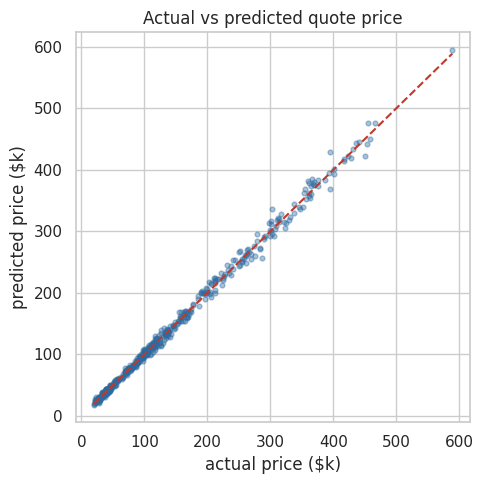

In [15]:
# Actual vs predicted price
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred, s=12, alpha=0.4, color='#2D6A9F')
lims = [y_test.min(), y_test.max()]; ax.plot(lims, lims, color='#C0392B', ls='--')
ax.set_xlabel('actual price ($k)'); ax.set_ylabel('predicted price ($k)')
ax.set_title('Actual vs predicted quote price'); plt.tight_layout(); plt.show()

### Visualize Feature Importance of the Leak-Free Model

/tmp/ipykernel_5581/3578804084.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.head(20).values, y=feature_importance.head(20).index, palette='viridis')


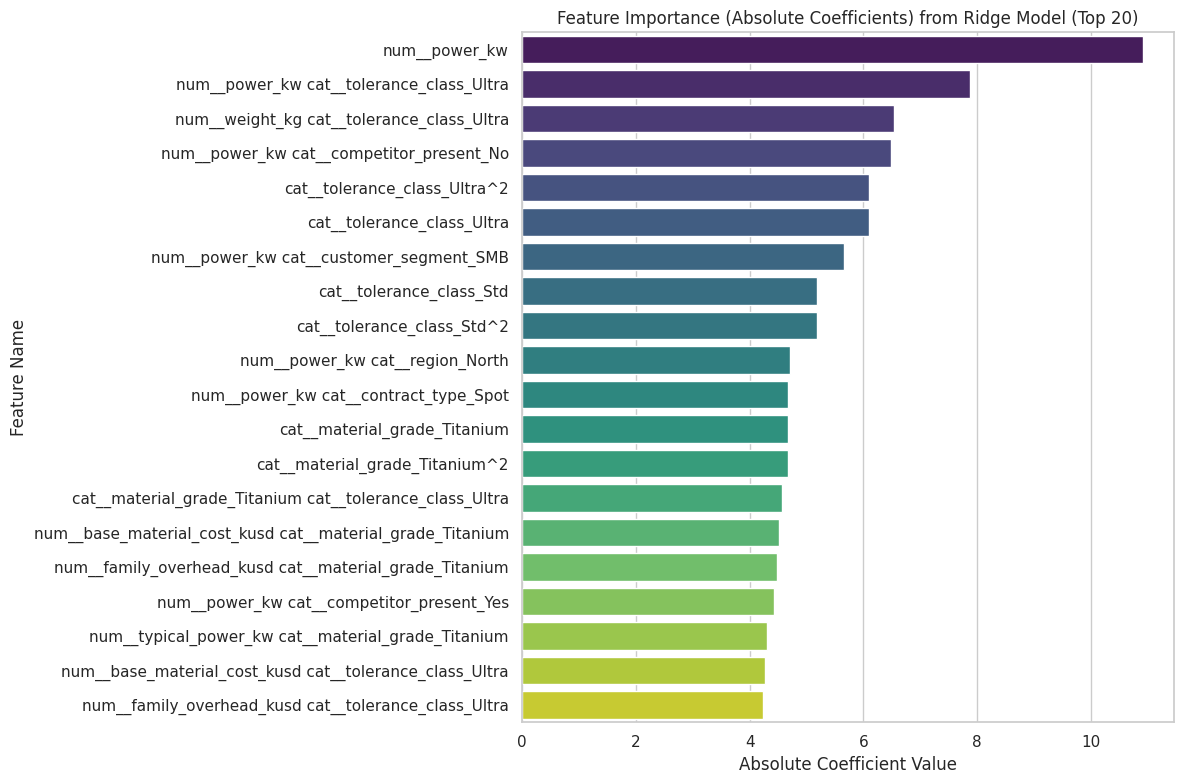

In [16]:
pre_feature_names = final_model.named_steps['prep'].get_feature_names_out()
feature_names = final_model.named_steps['poly'].get_feature_names_out(pre_feature_names)
coefs = final_model.named_steps['ridge'].coef_

# Create a Series for better handling and sorting
feature_importance = pd.Series(coefs, index=feature_names)

# Sort the features by their absolute importance
feature_importance = feature_importance.abs().sort_values(ascending=False)

# Plot the top N features (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance.head(20).values, y=feature_importance.head(20).index, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients) from Ridge Model (Top 20)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

#### 🧪 EXERCISE 4 — Translate error into business terms
1. Compute the **median** absolute error in $k.
2. For a typical $150k machine, what does the MAPE imply in dollar terms?
3. In a comment, state whether this accuracy is good enough to *assist* a sales engineer (not replace).

In [17]:
from sklearn.metrics import median_absolute_error

# 1. median absolute error
median_ae = median_absolute_error(y_test, pred)
print(f'Median Absolute Error: {median_ae:.2f} $k')

# 2. MAPE on a $150k machine (in $)
mape_150k_machine = (mape / 100) * 150
print(f'MAPE for a $150k machine: ${mape_150k_machine:.2f}k')

# 3. good enough to assist? ...   (comment)

Median Absolute Error: 2.70 $k
MAPE for a $150k machine: $5.95k


# 3. good enough to assist? (comment)

Given the Median Absolute Error of **$2.70k** and a MAPE of approximately **$6.00k** on a $150k machine, this model's accuracy is likely good enough to *assist* a sales engineer.

*   An error of $2,700 (median) or $6,000 (for a $150k machine on average) is a reasonable margin for a human sales engineer to work with.
*   The model can provide a strong starting point for quotes, flag potential outliers, and help ensure consistency across different sales personnel.
*   It should not replace the sales engineer entirely, as human judgment is still crucial for complex negotiations, customer relationships, and market nuances not captured in the data. However, it can significantly improve efficiency and consistency.

## 8. Stage 5 — What drives the price? & recommendations

In [18]:
# -----------------------------------------------------------
# 🔹 8A. A SIMPLE, INTERPRETABLE MODEL FOR THE DRIVERS
# -----------------------------------------------------------
interp = Pipeline([('prep', pre), ('ridge', Ridge(alpha=best[2]))]).fit(X_train, y_train)
feat_names = interp.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(interp.named_steps['ridge'].coef_, index=feat_names)
print('Top price-INCREASING factors:')
print(coefs.sort_values(ascending=False).head(6).round(2))
print('\nTop price-DECREASING factors:')
print(coefs.sort_values().head(4).round(2))

Top price-INCREASING factors:
num__power_kw                   38.21
cat__tolerance_class_Ultra      25.10
cat__material_grade_Titanium    16.52
num__family_overhead_kusd       15.55
num__base_material_cost_kusd    15.49
num__typical_power_kw           14.93
dtype: float64

Top price-DECREASING factors:
cat__tolerance_class_Std        -20.65
cat__material_grade_Standard    -11.55
cat__material_grade_Stainless    -5.94
num__order_quantity              -5.72
dtype: float64


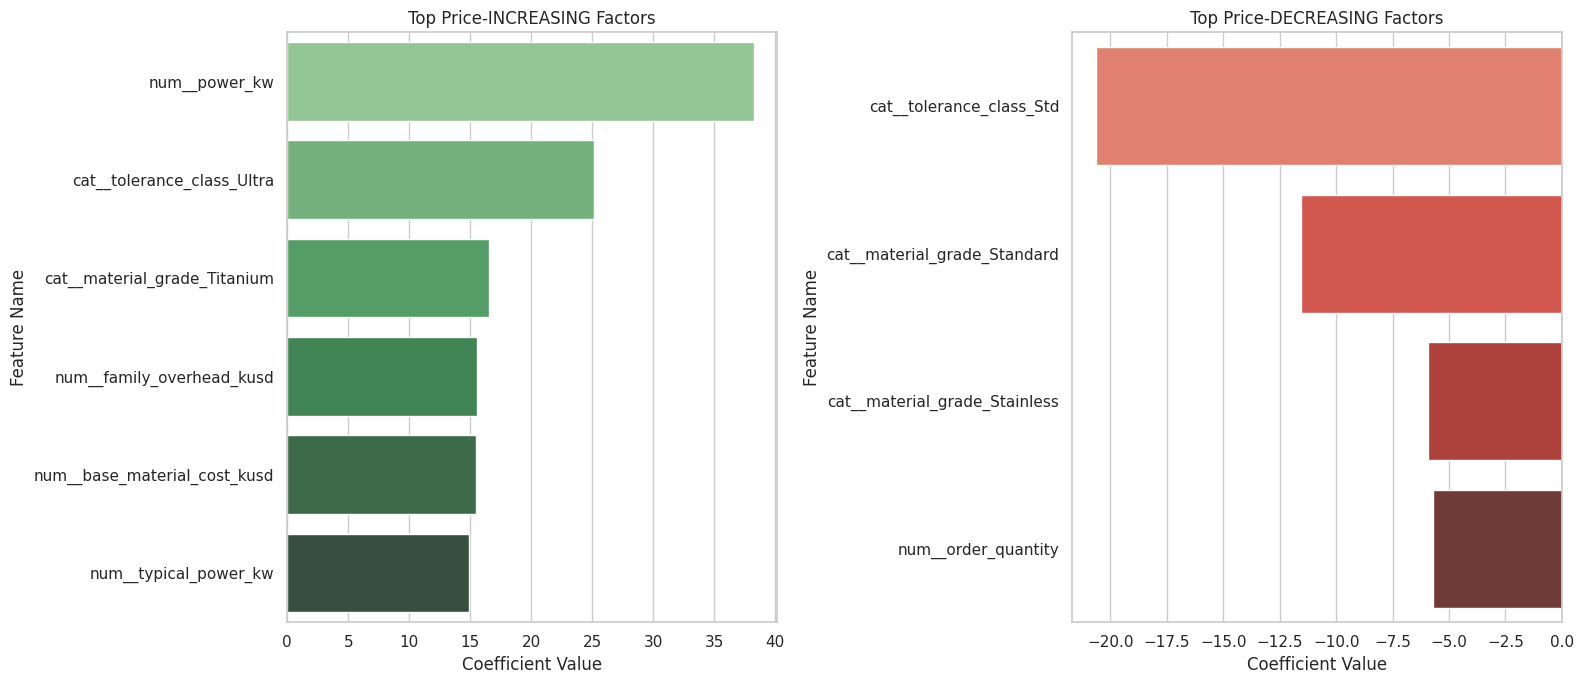

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Re-create the interpretable model and extract coefficients to ensure they are in scope
# These variables (pre, best, X_train, y_train) are expected to be available from prior cells.
interp = Pipeline([('prep', pre), ('ridge', Ridge(alpha=best[2]))]).fit(X_train, y_train)
feat_names = interp.named_steps['prep'].get_feature_names_out()
raw_coefs = interp.named_steps['ridge'].coef_

# Convert raw_coefs (numpy array) into a Pandas Series with feature names as index
coefs = pd.Series(raw_coefs, index=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plotting Top Price-INCREASING factors
sns.barplot(x=coefs.sort_values(ascending=False).head(6).values, y=coefs.sort_values(ascending=False).head(6).index, palette='Greens_d', hue=coefs.sort_values(ascending=False).head(6).index, legend=False, ax=axes[0])
axes[0].set_title('Top Price-INCREASING Factors')
axes[0].set_xlabel('Coefficient Value')
axes[0].set_ylabel('Feature Name')

# Plotting Top Price-DECREASING factors
sns.barplot(x=coefs.sort_values(ascending=True).head(4).values, y=coefs.sort_values(ascending=True).head(4).index, palette='Reds_d', hue=coefs.sort_values(ascending=True).head(4).index, legend=False, ax=axes[1])
axes[1].set_title('Top Price-DECREASING Factors')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_ylabel('Feature Name')

plt.tight_layout()
plt.show()

## Findings & recommendations

- **Engineering specs dominate price:** power rating, custom machining and premium materials (alloy/titanium) are the biggest upward drivers — exactly what an estimator would expect.
- **Sales context discounts price:** enterprise customers, competitor-present deals and framework contracts pull the quote down — the model has learned the negotiation reality.
- **Leakage was real and dangerous:** `gross_margin_kusd` looked like a star predictor but is only known *after* the deal — including it would have produced a model that fails in production.
- **Generalisation was tuned, not assumed:** scaling made optimisation work; the complexity curve and Ridge alpha were chosen by cross-validation so the model performs on unseen quotes.

**Deployment guidance:** use the model to *suggest* a starting quote and flag unusual deals; never feed it post-deal fields; retrain as the catalog and market move.

**Pipeline status:** ML-ready dataset → optimised training → regularised, bias-variance-balanced model → evaluated in business terms. Next: hyperparameter search, richer models (gradient boosting), and a monitored deployment.

## 9. 🧪 Capstone extension challenges

1. **Beat the baseline:** try `GradientBoostingRegressor` in the same pipeline; compare test RMSE & MAPE with the Ridge model.
2. **Per-family error:** compute test MAPE split by `product_family` — where is the model weakest?
3. **Lasso for selection:** fit a `Lasso` on the scaled features; list which inputs it zeroes out.
4. **Quote band:** instead of a point price, output a ±1 RMSE range as a 'recommended quote band' and explain in a markdown cell why a range is more useful to a sales engineer than a single number.

### 🧪 Challenge 1 — Beat the baseline: GradientBoostingRegressor

I will train a `GradientBoostingRegressor` using the same preprocessing steps (imputation, scaling, one-hot encoding, and polynomial features of degree 2) as the best `Ridge` model. Then, I'll compare its test RMSE and MAPE to see if it outperforms the Ridge baseline.

In [22]:
# Space for your challenge work
from sklearn.ensemble import GradientBoostingRegressor

# Create a pipeline with GradientBoostingRegressor
# We'll use the same preprocessing steps as the best Ridge model (degree=2)
# Note: GradientBoostingRegressor typically doesn't need scaling after PolynomialFeatures as much as linear models,
# but keeping it consistent with the existing pipeline for fair comparison.

gbr_model = Pipeline([
    ('prep', pre),
    ('poly', PolynomialFeatures(best[1], include_bias=False)), # best[1] is the degree (2)
    ('gbr', GradientBoostingRegressor(random_state=42)) # Using default parameters for initial comparison
])

# Fit the GradientBoostingRegressor model
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
pred_gbr = gbr_model.predict(X_test)

# Calculate RMSE and MAPE for the GBR model
rmse_gbr = mean_squared_error(y_test, pred_gbr) ** 0.5
mape_gbr = (np.abs((y_test - pred_gbr) / y_test)).mean() * 100

print(f'GradientBoostingRegressor Test RMSE: {rmse_gbr:.2f} $k')
print(f'GradientBoostingRegressor Test MAPE: {mape_gbr:.1f}%')

print('\n--- Comparison with Ridge Model ---')
print(f'Ridge Model Test RMSE: {rmse:.2f} $k')
print(f'Ridge Model Test MAPE: {mape:.1f}%')

if rmse_gbr < rmse:
    print('\nGradientBoostingRegressor achieved lower RMSE.')
else:
    print('\nRidge Model achieved lower or equal RMSE.')

if mape_gbr < mape:
    print('GradientBoostingRegressor achieved lower MAPE.')
else:
    print('Ridge Model achieved lower or equal MAPE.')

GradientBoostingRegressor Test RMSE: 9.46 $k
GradientBoostingRegressor Test MAPE: 5.3%

--- Comparison with Ridge Model ---
Ridge Model Test RMSE: 6.21 $k
Ridge Model Test MAPE: 4.0%

Ridge Model achieved lower or equal RMSE.
Ridge Model achieved lower or equal MAPE.


### 🧪 Challenge 2 — Per-family error

I will compute the test MAPE split by `product_family` to identify where the model is weakest. This involves predicting prices on the test set using our best `Ridge` model (`final_model`), calculating the absolute percentage error for each prediction, and then grouping by `product_family` to get the average MAPE.

Test MAPE per product_family (ordered by highest error):
product_family
Valve-Z         6.33
Pump-A          4.64
Pump-B          3.35
Compressor-Y    3.26
Compressor-X    3.23
Turbine-T       2.59
Name: abs_perc_error, dtype: float64


/tmp/ipykernel_5581/1476675894.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mape_per_family.values, y=mape_per_family.index, palette='viridis')


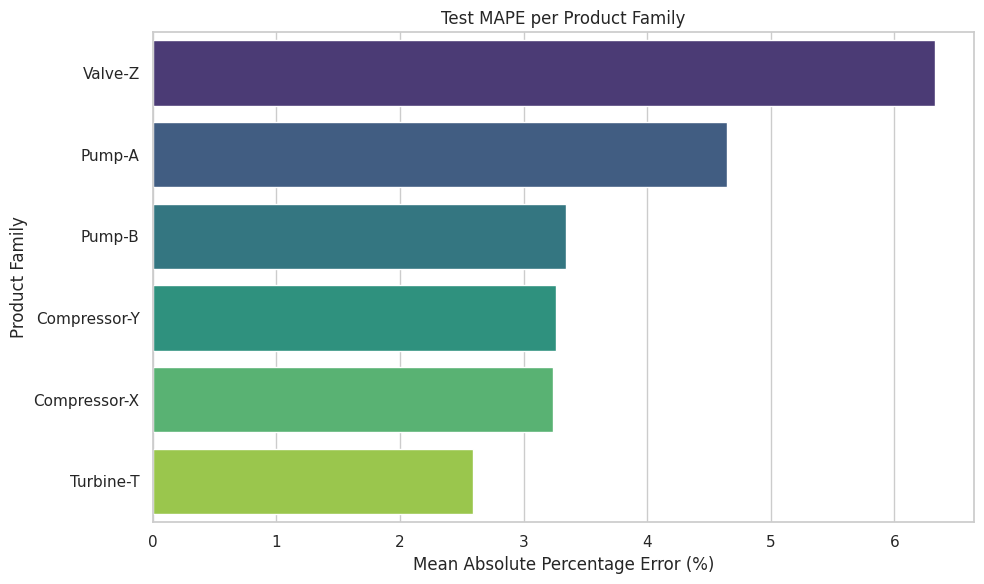

In [23]:
# Make predictions using the final_model (Ridge model) on the test set
pred_ridge = final_model.predict(X_test)

# Create a DataFrame to hold product family, actual prices, and predicted prices
# We need the product_family column from the original X_test DataFrame
results_df = pd.DataFrame({
    'product_family': X_test['product_family'],
    'actual_price': y_test,
    'predicted_price': pred_ridge
})

# Calculate Absolute Percentage Error for each prediction
results_df['abs_perc_error'] = np.abs((results_df['actual_price'] - results_df['predicted_price']) / results_df['actual_price']) * 100

# Calculate MAPE for each product family
mape_per_family = results_df.groupby('product_family')['abs_perc_error'].mean().sort_values(ascending=False)

print('Test MAPE per product_family (ordered by highest error):')
print(mape_per_family.round(2))

# Plot the MAPE per product family
plt.figure(figsize=(10, 6))
sns.barplot(x=mape_per_family.values, y=mape_per_family.index, palette='viridis')
plt.title('Test MAPE per Product Family')
plt.xlabel('Mean Absolute Percentage Error (%)')
plt.ylabel('Product Family')
plt.tight_layout()
plt.show()

### 🧪 Challenge 3 — Lasso for selection

I will fit a `Lasso` model on the scaled features (with polynomial transformation as before) and list which inputs it zeroes out. Lasso regression is known for its ability to perform feature selection by shrinking the coefficients of less important features to zero.

In [24]:
from sklearn.linear_model import Lasso

# Create a pipeline with Lasso, using the same preprocessing as the Ridge model
# We will use the best degree (2) from the Ridge model for consistency.
# We need to tune alpha for Lasso as well; starting with a value similar to Ridge's best_alpha
# Lasso can be sensitive to scaling, which our 'pre' step handles.

# Instantiate the Lasso model with an initial alpha (e.g., best_alpha from Ridge)
# You might need to experiment with alpha for Lasso, as its behavior can differ from Ridge
lasso_model = Pipeline([
    ('prep', pre),
    ('poly', PolynomialFeatures(best[1], include_bias=False)), # best[1] is the degree (2)
    ('lasso', Lasso(alpha=best_alpha, random_state=42, max_iter=2000)) # Increase max_iter for convergence if needed
])

# Fit the Lasso model
lasso_model.fit(X_train, y_train)

# Extract feature names after preprocessing and polynomial transformation
pre_feature_names_lasso = lasso_model.named_steps['prep'].get_feature_names_out()
feature_names_lasso = lasso_model.named_steps['poly'].get_feature_names_out(pre_feature_names_lasso)

# Get the coefficients from the Lasso model
lasso_coefs = pd.Series(lasso_model.named_steps['lasso'].coef_, index=feature_names_lasso)

# Identify features with zero coefficients
zeroed_out_features = lasso_coefs[lasso_coefs == 0].index.tolist()

print(f'Lasso model (alpha={best_alpha:.3f}) zeroed out {len(zeroed_out_features)} features.')
if zeroed_out_features:
    print('Features zeroed out by Lasso:')
    for feature in zeroed_out_features:
        print(f'- {feature}')
else:
    print('No features were completely zeroed out by Lasso with the current alpha.')

# Optionally, print all non-zero coefficients for inspection
# print('\nNon-zero coefficients:')
# print(lasso_coefs[lasso_coefs != 0].sort_values(ascending=False).round(3))

Lasso model (alpha=6.661) zeroed out 693 features.
Features zeroed out by Lasso:
- num__weight_kg
- num__pressure_bar
- num__order_quantity
- num__lead_time_days
- num__family_overhead_kusd
- cat__product_family_Compressor-X
- cat__product_family_Compressor-Y
- cat__product_family_Pump-A
- cat__product_family_Pump-B
- cat__product_family_Turbine-T
- cat__product_family_Valve-Z
- cat__material_grade_Alloy
- cat__material_grade_Stainless
- cat__material_grade_Standard
- cat__material_grade_Titanium
- cat__tolerance_class_Precision
- cat__tolerance_class_Ultra
- cat__customer_segment_Enterprise
- cat__customer_segment_MidMarket
- cat__customer_segment_SMB
- cat__region_East
- cat__region_North
- cat__region_South
- cat__region_West
- cat__competitor_present_No
- cat__competitor_present_Yes
- cat__contract_type_Annual
- cat__contract_type_Framework
- cat__contract_type_Spot
- num__power_kw^2
- num__power_kw num__weight_kg
- num__power_kw num__pressure_bar
- num__power_kw num__custom_machin

### Visualize Non-Zero Lasso Coefficients

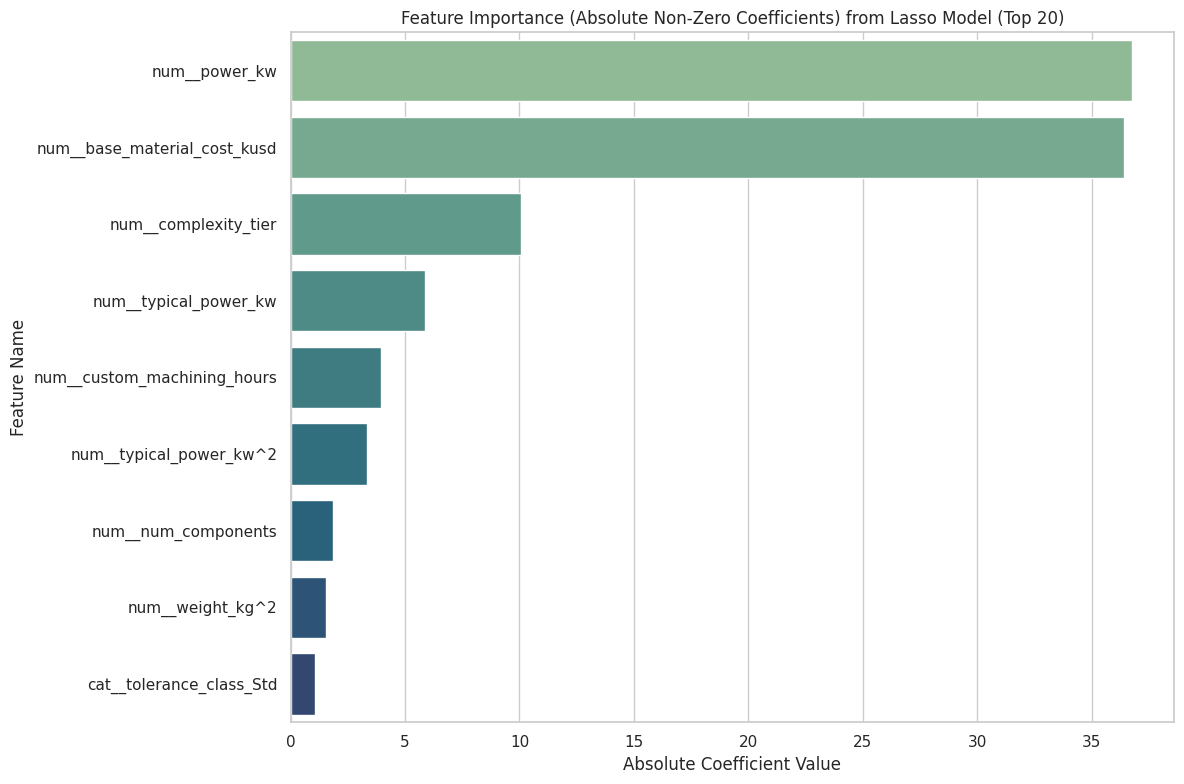

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for non-zero coefficients
non_zero_lasso_coefs = lasso_coefs[lasso_coefs != 0]

# Sort by absolute value for importance visualization
feature_importance_lasso = non_zero_lasso_coefs.abs().sort_values(ascending=False)

# Plot the top N features (e.g., top 20 non-zero features)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_lasso.head(20).values, y=feature_importance_lasso.head(20).index, palette='crest', hue=feature_importance_lasso.head(20).index, legend=False)
plt.title('Feature Importance (Absolute Non-Zero Coefficients) from Lasso Model (Top 20)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Evaluate Lasso Model Performance and Compare with Ridge

In [27]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set using the fitted Lasso model
pred_lasso = lasso_model.predict(X_test)

# Calculate RMSE and MAPE for the Lasso model
rmse_lasso = mean_squared_error(y_test, pred_lasso) ** 0.5
mape_lasso = (np.abs((y_test - pred_lasso) / y_test)).mean() * 100

print(f'Lasso Model Test RMSE: {rmse_lasso:.2f} $k')
print(f'Lasso Model Test MAPE: {mape_lasso:.1f}%')

print('\n--- Comparison of Ridge vs Lasso Model ---')
print(f'Ridge Model Test RMSE: {rmse:.2f} $k')
print(f'Ridge Model Test MAPE: {mape:.1f}%')

print(f'\nLasso Model Test RMSE: {rmse_lasso:.2f} $k')
print(f'Lasso Model Test MAPE: {mape_lasso:.1f}%')

if rmse_lasso < rmse:
    print('\nLasso Model achieved lower RMSE.')
else:
    print('\nRidge Model achieved lower or equal RMSE.')

if mape_lasso < mape:
    print('Lasso Model achieved lower MAPE.')
else:
    print('Ridge Model achieved lower or equal MAPE.')

Lasso Model Test RMSE: 26.00 $k
Lasso Model Test MAPE: 16.8%

--- Comparison of Ridge vs Lasso Model ---
Ridge Model Test RMSE: 6.21 $k
Ridge Model Test MAPE: 4.0%

Lasso Model Test RMSE: 26.00 $k
Lasso Model Test MAPE: 16.8%

Ridge Model achieved lower or equal RMSE.
Ridge Model achieved lower or equal MAPE.


### 🧪 Challenge 4 — Quote band

Instead of a point price, I will output a ±1 RMSE range as a 'recommended quote band'. This range provides a confidence interval around the predicted price, acknowledging the inherent uncertainty in any forecast. Below, I'll explain why a range is more useful to a sales engineer than a single number.

In [29]:
# Calculate predictions using the final_model (Ridge model) on the test set
pred = final_model.predict(X_test)

# The RMSE was previously calculated as 'rmse'
# rmse = mean_squared_error(y_test, pred) ** 0.5 (from WQ5iIxO1-7Mo)

# Calculate the lower and upper bounds of the quote band
lower_bound = pred - rmse
upper_bound = pred + rmse

# Create a DataFrame to display the quote bands for a few examples
quote_bands_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': pred,
    'Lower Bound (-1 RMSE)': lower_bound,
    'Upper Bound (+1 RMSE)': upper_bound
})

print(f'Using RMSE: {rmse:.2f} $k for the quote band.')
print('\nRecommended Quote Bands (first 10 test examples):')
display(quote_bands_df.head(10).style.format({
    'Actual Price': '{:,.2f} $k',
    'Predicted Price': '{:,.2f} $k',
    'Lower Bound (-1 RMSE)': '{:,.2f} $k',
    'Upper Bound (+1 RMSE)': '{:,.2f} $k'
}))

Using RMSE: 6.21 $k for the quote band.

Recommended Quote Bands (first 10 test examples):


,Actual Price,Predicted Price,Lower Bound (-1 RMSE),Upper Bound (+1 RMSE)
1451,23.39 $k,23.16 $k,16.94 $k,29.37 $k
1334,27.69 $k,24.34 $k,18.12 $k,30.55 $k
1761,33.40 $k,36.86 $k,30.64 $k,43.07 $k
1735,110.92 $k,116.04 $k,109.83 $k,122.25 $k
1576,453.87 $k,441.28 $k,435.06 $k,447.49 $k
1110,185.39 $k,195.42 $k,189.20 $k,201.63 $k
1594,107.61 $k,108.68 $k,102.47 $k,114.90 $k
530,49.05 $k,50.00 $k,43.79 $k,56.21 $k
651,28.57 $k,25.66 $k,19.45 $k,31.88 $k
819,169.60 $k,161.49 $k,155.28 $k,167.70 $k


### Why a Quote Band is More Useful to a Sales Engineer than a Single Number

A single predicted price provides a definitive estimate, but in the complex world of sales, it can be misleading due to inherent model uncertainty and market fluctuations. A **recommended quote band** (e.g., ±1 RMSE) offers several advantages:

1.  **Reflects Uncertainty:** It explicitly communicates the model's confidence. Sales engineers understand that no prediction is perfect, and a range helps them manage customer expectations and internal pricing strategies.

2.  **Negotiation Flexibility:** It provides a realistic negotiation window. Instead of being anchored to a single number, the sales engineer has a defined upper and lower boundary within which they can operate, allowing for tactical adjustments during discussions with the client.

3.  **Risk Management:** The lower bound can represent the minimum acceptable price for profitability, while the upper bound might be the aspirational or competitive maximum. This helps in understanding the financial risk and potential upside of a deal.

4.  **Informed Decision-Making:** For deals falling outside this band, it can serve as an alert. If a customer is asking for a price significantly below the lower bound, it might signal a need for special approval, a deeper discount strategy, or a re-evaluation of the deal's viability. Conversely, if the customer is willing to pay above the upper bound, it highlights an opportunity.

5.  **Builds Trust:** Presenting a realistic range, rather than an overly precise single figure, can foster greater trust in the model as a practical tool rather than an infallible oracle.

In essence, the quote band empowers sales engineers with actionable intelligence, blending the model's predictive power with the necessary human judgment for successful deal closures.

### Residual Analysis for Ridge Model

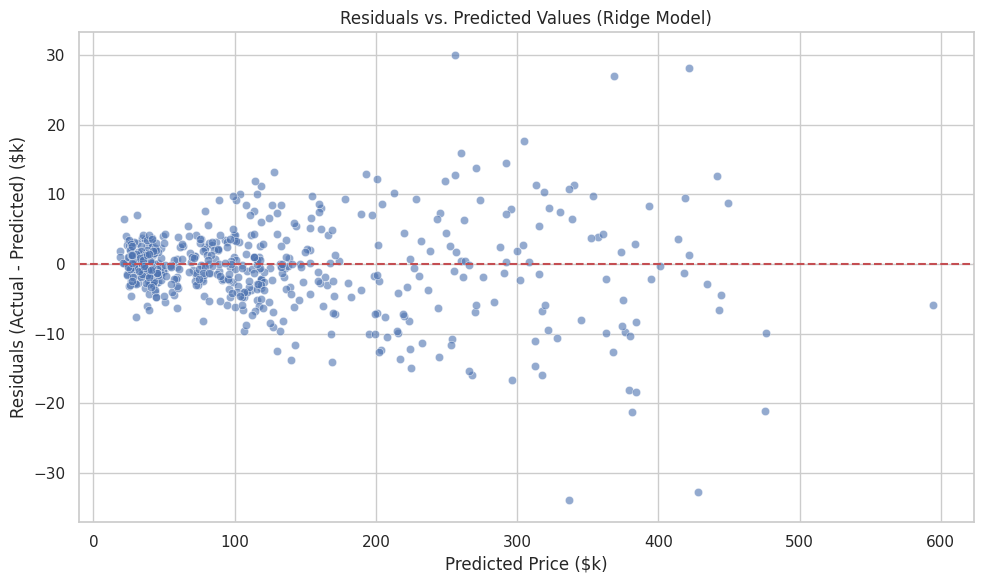

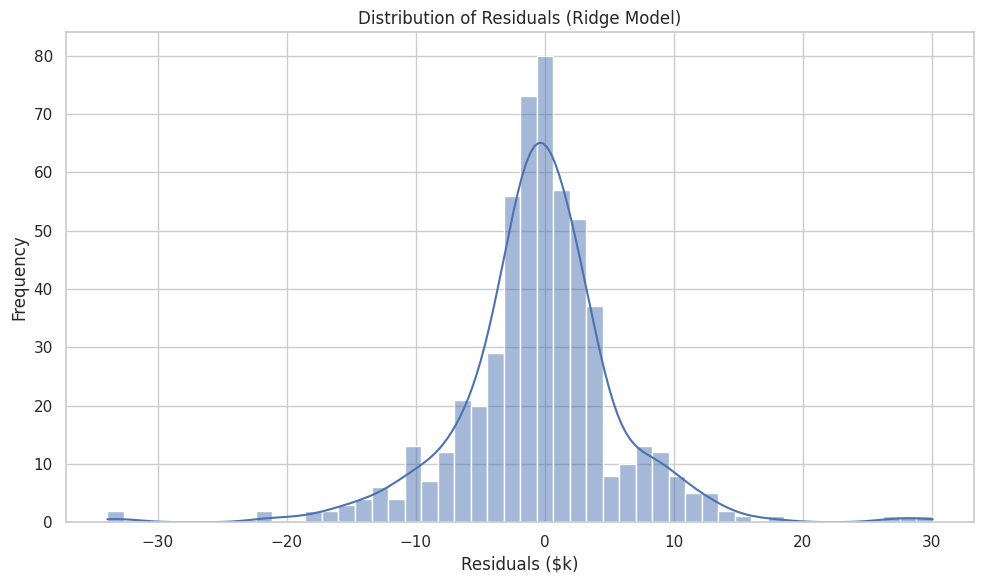

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Ridge Model)')
plt.xlabel('Predicted Price ($k)')
plt.ylabel('Residuals (Actual - Predicted) ($k)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals (Ridge Model)')
plt.xlabel('Residuals ($k)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Residuals vs. Actual Values Plot (Ridge Model)

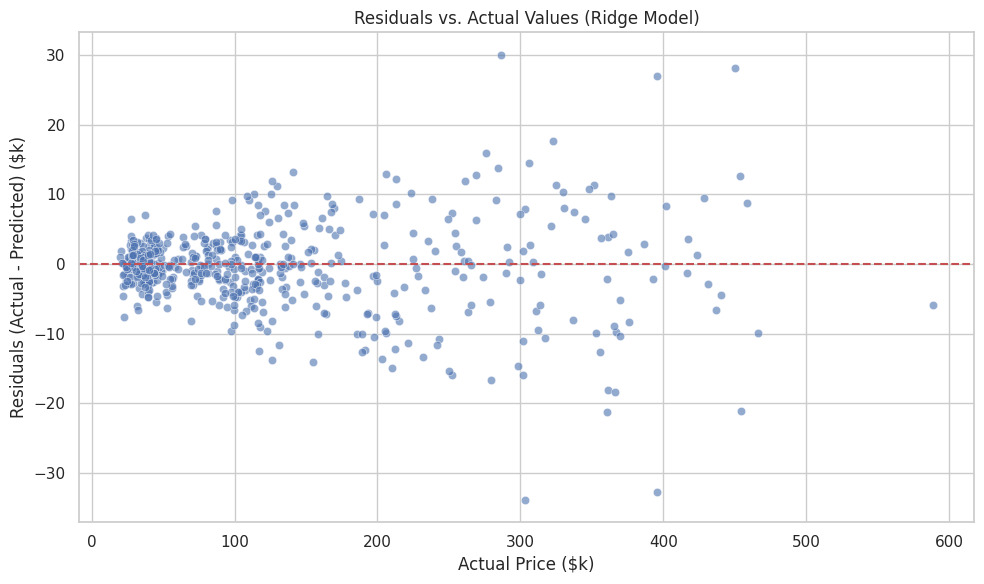

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting residuals vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Actual Values (Ridge Model)')
plt.xlabel('Actual Price ($k)')
plt.ylabel('Residuals (Actual - Predicted) ($k)')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### ✅ Capstone complete
You assembled a leak-free, model-ready dataset from engineering + sales sources; trained it well (scaling, optimiser, learning rate); and tuned complexity and regularisation so it **generalises** to new quotes — then translated the error into dollars a sales engineer can act on. That is the Day-6 workflow: not just fitting a model, but training one you can trust.